In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv('Data/hotel_booking_cleaned_data.csv')
df.head()

,Customer_ID,Customer Country,Booking_ID,Hotel,City,Booking Date,Lead Time,Arrival Date,Adults,Childrens,...,No. of Week Nights,Total Nights Stay,Meal Type,Booking Status,Customer Cancel Count,Average Daily Rate,Market Segment,Reserved Room Type,Assigned Room Type,Special Request
0,CUST_570,India,INN00001,Resort Hotel,Hyderabad,20-Aug-23,342,27-Jul-24,2,0,...,5,7,Breakfast,0,1,135,Online Self / TA,Deluxe,Premium,0
1,CUST_164,UK,INN00002,Resort Hotel,Goa,20-Mar-23,405,28-Apr-24,2,0,...,3,4,Not Selected,1,1,0,Online Self / TA,Deluxe,Deluxe,0
2,CUST_420,India,INN00003,Resort Hotel,Mumbai,3-Sep-24,7,10-Sep-24,2,0,...,3,4,Breakfast,0,0,75,Direct,Standard,Standard,0
3,CUST_278,Australia,INN00004,City Hotel,Kochi,1-Aug-24,13,14-Aug-24,2,0,...,2,2,Breakfast,1,1,75,Online Self / TA,Standard,Standard,0
4,CUST_572,India,INN00005,City Hotel,Jaipur,31-Aug-24,14,14-Sep-24,2,0,...,2,3,Not Selected,1,2,98,Online Self / TA,Standard,Deluxe,1


In [5]:
#Data Preprocessing 
# Clean column names
df.columns = df.columns.str.strip()

# ✔ Create Room Change FIRST (IMPORTANT)
df['Room Change'] = (df['Reserved Room Type'] != df['Assigned Room Type']).astype(int)

# Drop unnecessary columns
df = df.drop(['Customer_ID', 'Booking_ID', 'Booking Date', 'Arrival Date'], axis=1)

# THEN convert categorical
df = pd.get_dummies(df, drop_first=True)

In [6]:
#Define Features and Target
X = df.drop('Booking Status', axis=1)
y = df['Booking Status']
#Independent variables (X) include all features.
#Target variable (y) is Booking Status (0 = Not Cancelled, 1 = Cancelled).

In [7]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Data is split into 80% training and 20% testing.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)  # learn + transform
X_test = scaler.transform(X_test)        # only transform

In [9]:
#Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                            Feature  Coefficient
7             Customer Cancel Count     1.526424
38  Market Segment_Online Self / TA     0.462261
11          Customer Country_Canada     0.235779
17             Customer Country_USA     0.198755
15             Customer Country_UAE     0.194135
16              Customer Country_UK     0.187196
39       Reserved Room Type_Premium     0.184783
14           Customer Country_India     0.179778
13         Customer Country_Germany     0.126586
1                            Adults     0.064218
25                   City_Hyderabad     0.062194
21                  City_Chandigarh     0.061120
27                      City_Jaipur     0.058094
40      Reserved Room Type_Standard     0.053048
3                      Total Guests     0.047113
12          Customer Country_France     0.035966
22                     City_Chennai     0.027710
2                         Childrens     0.020394
18               Hotel_Resort Hotel     0.017327
35         Market Se

### Feature Importance Interpretation

The Logistic Regression coefficients show how different features influence booking cancellation.

* Features like **Customer Cancel Count**, **Online/TA market segment**, and **Premium room type** have positive coefficients, indicating a higher likelihood of cancellation.
* Customer demographics (country, city) and number of guests also have a moderate positive impact on cancellations.
* Features like **Lead Time**, **Group bookings**, and some cities show negative coefficients, indicating lower cancellation probability.

Overall, past cancellation behavior and booking type are the strongest predictors. These insights can help identify high-risk customers and improve retention strategies.


In [14]:
#Predictions
y_pred = model.predict(X_test)


In [15]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.755



The Logistic Regression model achieved an accuracy of **75.5% (~76%)**, indicating that it correctly predicts booking outcomes in most cases. Precision and recall show how effectively the model identifies cancellations.

False negatives are especially critical, as they represent missed cancellation predictions, which can lead to revenue loss due to unanticipated empty rooms.


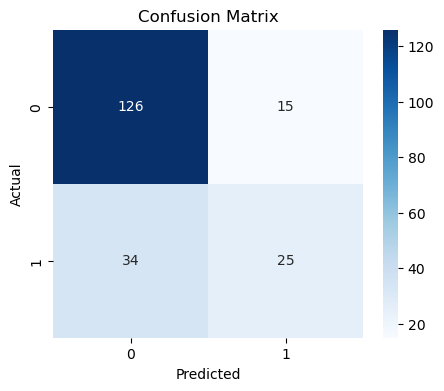

In [16]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In this confusion matrix:
- 0 represents Not Cancelled bookings
- 1 represents Cancelled bookings

The confusion matrix shows:
- 126 bookings were correctly predicted as not cancelled (True Negatives)
- 15 bookings were incorrectly predicted as cancelled (False Positives)
- 34 bookings were incorrectly predicted as not cancelled (False Negatives)
- 25 bookings were correctly predicted as cancelled (True Positives)

### Statistical Interpretation
The model performs well in identifying non-cancelled bookings, with a high number of correct predictions (126).
However, it struggles to correctly identify cancellations, as shown by a relatively higher number of false negatives (34).

This indicates that the model is better at predicting stable bookings than detecting cancellations.

In [46]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.89      0.84       141
           1       0.62      0.42      0.51        59

    accuracy                           0.76       200
   macro avg       0.71      0.66      0.67       200
weighted avg       0.74      0.76      0.74       200



### Classification Report
The classification report provides detailed performance metrics:

For Class 0 (Not Cancelled):
- Precision (0.79): 79% of predicted non-cancelled bookings are correct
- Recall (0.89): 89% of actual non-cancelled bookings are correctly identified
- F1-score (0.84): Strong overall performance for this class

For Class 1 (Cancelled):
- Precision (0.62): 62% of predicted cancellations are correct
- Recall (0.42): Only 42% of actual cancellations are detected
- F1-score (0.51): Moderate performance for cancellation prediction



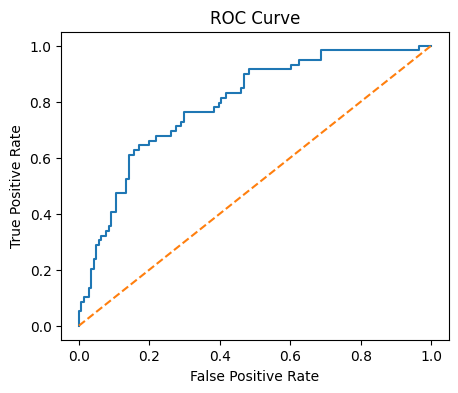

ROC-AUC Score: 0.7924029330448371


In [47]:
#For AUC-ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

### ROC-AUC Analysis:
The Logistic Regression model achieves a ROC-AUC score of 0.80, indicating good classification capability.
The curve stays well above the diagonal line, showing that the model performs better than random guessing.
Overall, the model is effective in identifying booking patterns, though there is still room for improvement in detecting cancellations.




-------------------------------------------------------------------------------------------------------------------------------

# Conclusion from Logistic Regression Model
- The Logistic Regression model demonstrates satisfactory overall performance, achieving an accuracy of 76% and a strong ROC-AUC score.
- The model is more effective in predicting non-cancelled bookings, as reflected by its higher precision and recall for this class.
- However, the relatively lower recall for cancelled bookings indicates that a significant number of cancellations are not correctly identified.

This highlights a limitation in the model’s ability to capture cancellation behavior, suggesting the need for further improvement through advanced techniques or model optimization.




# Business Insights:
- The model helps find customers who might cancel their bookings early, so the hotel can take action in advance.
- Online bookings have more chances of cancellation, so the hotel should confirm these bookings more carefully or ask for advance payment.


### Business Applications:
- This model can be used by hotels to predict booking cancellations in advance.
- It helps in better planning, reducing revenue loss, and improving customer management.